# Predictive Analytics for Healthcare: Forecasting Patient Length of Stay in Urban Hospitals

### IDRA Data Science & AI Capstone Project — Regression

**Target variable:** `lengthofstay`  
**Dataset:** `LengthOfStay.csv`  
**Primary model:** CatBoost Regression  
**Evaluation metrics:** MAE, MSE, RMSE, R²


## 1. Imports and Environment Setup

In [2]:
# Run this cell in Google Colab.
# CatBoost is used because it handles mixed numerical/categorical predictors effectively.

!pip -q install catboost

In [3]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Environment ready.")

Environment ready.


## 2. Dataset Loading

### 2.1 Upload the Dataset

If the CSV is already present in `/content`, the notebook will use it. Otherwise, Colab will open an upload box.

In [4]:
DATA_PATH = "/content/LengthOfStay.csv"

if not os.path.exists(DATA_PATH):
    from google.colab import files
    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))
    DATA_PATH = os.path.join("/content", uploaded_name)

df_raw = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df_raw.shape)
display(df_raw.head())

Saving LengthOfStay.csv to LengthOfStay.csv
Dataset loaded successfully.
Shape: (61680, 28)


,eid,vdate,rcount,gender,dialysisrenalendstage,asthma,irondef,pneum,substancedependence,psychologicaldisordermajor,depress,psychother,fibrosisandother,malnutrition,hemo,hematocrit,neutrophils,sodium,glucose,bloodureanitro,creatinine,bmi,pulse,respiration,secondarydiagnosisnonicd9,discharged,facid,lengthofstay
0,1,8/29/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.5,14.20,140.361132,192.476918,12.0,1.390722,30.432418,96,6.5,4,9/1/2012,B,3
1,2,5/26/2012,5+,F,0,0,0,0,0,0,0,0,0,0,0,9.0,4.10,136.731692,94.078507,8.0,0.943164,28.460516,61,6.5,1,6/2/2012,A,7
2,3,9/22/2012,1,F,0,0,0,0,0,0,0,0,0,0,0,8.4,8.90,133.058514,130.530524,12.0,1.065750,28.843812,64,6.5,2,9/25/2012,B,3
3,4,8/9/2012,0,F,0,0,0,0,0,0,0,0,0,0,0,11.9,9.40,138.994023,163.377028,12.0,0.906862,27.959007,76,6.5,1,8/10/2012,A,1
4,5,12/20/2012,0,F,0,0,0,1,0,1,0,0,0,0,0,9.1,9.05,138.634836,94.886654,11.5,1.242854,30.258927,67,5.6,2,12/24/2012,E,4


## 3. Dataset Description and Data Understanding

The project target is `lengthofstay`, a continuous numerical variable representing the patient's stay duration in days. The columns are inspected before any modelling decisions are made.

In [5]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])
print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

print("\nDescriptive statistics:")
display(df_raw.describe(include="all").T)

Rows: 61680
Columns: 28

Column names:
['eid', 'vdate', 'rcount', 'gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'discharged', 'facid', 'lengthofstay']

Data types:


,dtype
eid,int64
vdate,object
rcount,object
gender,object
dialysisrenalendstage,int64
asthma,int64
irondef,int64
pneum,int64
substancedependence,int64
psychologicaldisordermajor,int64



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
eid,61680.0,NaN,NaN,NaN,30840.5,17805.626639,1.0,15420.75,30840.5,46260.25,61680.0
vdate,61680,367,3/25/2012,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rcount,61680,6,0,33976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,61680,2,F,35704,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dialysisrenalendstage,61680.0,NaN,NaN,NaN,0.036365,0.187198,0.0,0.0,0.0,0.0,1.0
asthma,61680.0,NaN,NaN,NaN,0.034679,0.182967,0.0,0.0,0.0,0.0,1.0
irondef,61680.0,NaN,NaN,NaN,0.095542,0.293964,0.0,0.0,0.0,0.0,1.0
pneum,61680.0,NaN,NaN,NaN,0.039559,0.194922,0.0,0.0,0.0,0.0,1.0
substancedependence,61680.0,NaN,NaN,NaN,0.062954,0.242882,0.0,0.0,0.0,0.0,1.0
psychologicaldisordermajor,61680.0,NaN,NaN,NaN,0.236106,0.424691,0.0,0.0,0.0,0.0,1.0


### 3.1 Data Dictionary — Automatically Generated

In [6]:
data_dictionary = pd.DataFrame({
    "variable": df_raw.columns,
    "data_type": [str(df_raw[c].dtype) for c in df_raw.columns],
    "missing_values": [df_raw[c].isna().sum() for c in df_raw.columns],
    "unique_values": [df_raw[c].nunique(dropna=True) for c in df_raw.columns],
    "role": ["Target" if c == "lengthofstay" else "Feature / Identifier / Metadata"
             for c in df_raw.columns]
})

display(data_dictionary)

,variable,data_type,missing_values,unique_values,role
0,eid,int64,0,61680,Feature / Identifier / Metadata
1,vdate,object,0,367,Feature / Identifier / Metadata
2,rcount,object,0,6,Feature / Identifier / Metadata
3,gender,object,0,2,Feature / Identifier / Metadata
4,dialysisrenalendstage,int64,0,2,Feature / Identifier / Metadata
5,asthma,int64,0,2,Feature / Identifier / Metadata
6,irondef,int64,0,2,Feature / Identifier / Metadata
7,pneum,int64,0,2,Feature / Identifier / Metadata
8,substancedependence,int64,0,2,Feature / Identifier / Metadata
9,psychologicaldisordermajor,int64,0,2,Feature / Identifier / Metadata


## 4. Data Cleaning

The cleaning stage checks missing values, duplicate records, data types, inconsistent categorical values and outliers. Cleaning decisions are documented rather than applied blindly.

### 4.1 Missing Values

In [7]:
missing_summary = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_percent": (df_raw.isna().mean() * 100).round(3)
}).sort_values("missing_count", ascending=False)

display(missing_summary)

,missing_count,missing_percent
eid,0,0.0
vdate,0,0.0
rcount,0,0.0
gender,0,0.0
dialysisrenalendstage,0,0.0
asthma,0,0.0
irondef,0,0.0
pneum,0,0.0
substancedependence,0,0.0
psychologicaldisordermajor,0,0.0


**Interpretation:** The notebook reports missingness before modelling. If missing values are present, the modelling pipeline uses training-data-fitted imputation rather than calculating replacement values from the full dataset, reducing the risk of data leakage.

### 4.2 Duplicate Records

In [8]:
duplicate_count = df_raw.duplicated().sum()
print("Duplicate rows:", duplicate_count)

df = df_raw.drop_duplicates().copy()
print("Shape before:", df_raw.shape)
print("Shape after :", df.shape)

Duplicate rows: 0
Shape before: (61680, 28)
Shape after : (61680, 28)


### 4.3 Data Types and Consistency Checks

In [9]:
# Check categorical values
for col in ["gender", "rcount", "facid"]:
    if col in df.columns:
        print(f"\n{col} unique values:", sorted(df[col].dropna().astype(str).unique().tolist()))

# Convert date columns to datetime
df["vdate"] = pd.to_datetime(df["vdate"], errors="coerce")
df["discharged"] = pd.to_datetime(df["discharged"], errors="coerce")

print("\nInvalid/missing dates after conversion:")
print("vdate:", df["vdate"].isna().sum())
print("discharged:", df["discharged"].isna().sum())

# Normalize simple categorical text
for col in ["gender", "facid"]:
    df[col] = df[col].astype("string").str.strip().str.upper()

print("\nUnique rcount values:", df["rcount"].unique())


gender unique values: ['F', 'M']

rcount unique values: ['0', '1', '2', '3', '4', '5+']

facid unique values: ['A', 'B', 'C', 'D', 'E']

Invalid/missing dates after conversion:
vdate: 0
discharged: 0

Unique rcount values: ['0' '5+' '1' '3' '4' '2']


### 4.4 Target Validation

`lengthofstay` should be a positive continuous/count-like outcome. We inspect impossible values and the distribution before deciding how to handle unusual observations.

In [10]:
print("Target missing values:", df["lengthofstay"].isna().sum())
print("Target <= 0:", (df["lengthofstay"] <= 0).sum())
print("\nTarget summary:")
display(df["lengthofstay"].describe())

Target missing values: 0
Target <= 0: 0

Target summary:


,lengthofstay
count,61680.000000
mean,3.999368
std,2.357744
min,1.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,17.000000


### 4.5 Outlier Analysis

In [11]:
Q1 = df["lengthofstay"].quantile(0.25)
Q3 = df["lengthofstay"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

target_outliers = ((df["lengthofstay"] < lower) | (df["lengthofstay"] > upper)).sum()

print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"IQR bounds = [{lower:.2f}, {upper:.2f}]")
print(f"Potential IQR outliers = {target_outliers}")

# We retain valid observations rather than deleting them solely because they are statistical outliers.
print("\nDecision: valid length-of-stay observations are retained; no arbitrary row deletion is performed.")

Q1 = 2.00
Q3 = 6.00
IQR = 4.00
IQR bounds = [-4.00, 12.00]
Potential IQR outliers = 83

Decision: valid length-of-stay observations are retained; no arbitrary row deletion is performed.


### 4.6 Before vs After Cleaning Summary

In [12]:
quality_before_after = pd.DataFrame({
    "Measure": [
        "Rows",
        "Columns",
        "Duplicate rows",
        "Total missing values",
        "Non-positive target values"
    ],
    "Before cleaning": [
        len(df_raw),
        df_raw.shape[1],
        df_raw.duplicated().sum(),
        int(df_raw.isna().sum().sum()),
        int((pd.to_numeric(df_raw["lengthofstay"], errors="coerce") <= 0).sum())
    ],
    "After cleaning": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        int(df.isna().sum().sum()),
        int((df["lengthofstay"] <= 0).sum())
    ]
})
display(quality_before_after)

,Measure,Before cleaning,After cleaning
0,Rows,61680,61680
1,Columns,28,28
2,Duplicate rows,0,0
3,Total missing values,0,0
4,Non-positive target values,0,0


## 5. Data Preprocessing



In [13]:
# Create admission-date features from vdate.
df_model = df.copy()

df_model["admit_year"] = df_model["vdate"].dt.year
df_model["admit_month"] = df_model["vdate"].dt.month
df_model["admit_day"] = df_model["vdate"].dt.day
df_model["admit_dayofweek"] = df_model["vdate"].dt.dayofweek
df_model["admit_quarter"] = df_model["vdate"].dt.quarter

# Convert rcount's "5+" category into its lower-bound numeric representation.
df_model["rcount_num"] = df_model["rcount"].replace({"5+": "5"}).astype(float)

# Explicitly remove leakage / identifier columns.
drop_cols = ["lengthofstay", "eid", "vdate", "discharged", "rcount"]
X = df_model.drop(columns=drop_cols)
y = df_model["lengthofstay"].astype(float)

print("Final feature columns:")
print(X.columns.tolist())
print("\nTarget:", y.name)
print("X shape:", X.shape, "| y shape:", y.shape)

Final feature columns:
['gender', 'dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'facid', 'admit_year', 'admit_month', 'admit_day', 'admit_dayofweek', 'admit_quarter', 'rcount_num']

Target: lengthofstay
X shape: (61680, 29) | y shape: (61680,)


### 5.1 Train-Test Split

An 80/20 split is used with a fixed random state for reproducibility. The test set remains unseen during model fitting and model selection decisions.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (49344, 29)
Testing set : (12336, 29)


### 5.2 Identify Numerical and Categorical Features

In [15]:
categorical_features = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:", categorical_features)
print("Numerical features:", numeric_features)

Categorical features: ['gender', 'facid']
Numerical features: ['dialysisrenalendstage', 'asthma', 'irondef', 'pneum', 'substancedependence', 'psychologicaldisordermajor', 'depress', 'psychother', 'fibrosisandother', 'malnutrition', 'hemo', 'hematocrit', 'neutrophils', 'sodium', 'glucose', 'bloodureanitro', 'creatinine', 'bmi', 'pulse', 'respiration', 'secondarydiagnosisnonicd9', 'admit_year', 'admit_month', 'admit_day', 'admit_dayofweek', 'admit_quarter', 'rcount_num']


## 6. Exploratory Data Analysis

The EDA focuses on charts that answer project questions rather than generating a large number of unrelated plots.

### 6.1 Univariate Analysis — Length of Stay Distribution

In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df["lengthofstay"], bins=17, kde=True)
plt.title("Distribution of Patient Length of Stay")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

print("Mean:", round(df["lengthofstay"].mean(), 3))
print("Median:", round(df["lengthofstay"].median(), 3))

### 6.2 Categorical Analysis — Facility and Length of Stay

In [ ]:
facility_summary = (
    df.groupby("facid")["lengthofstay"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

display(facility_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="facid", y="lengthofstay")
plt.title("Length of Stay Across Hospital Facilities")
plt.xlabel("Facility")
plt.ylabel("Length of Stay (days)")
plt.tight_layout()
plt.show()

### 6.3 Clinical/Operational Relationship — Hemoglobin-related Measure

In [ ]:

plt.figure(figsize=(9, 6))

ax = sns.boxplot(
    data=df,
    x="hemo",
    y="lengthofstay"
)

# Add mean points
means = df.groupby("hemo")["lengthofstay"].mean()

for i, mean_value in enumerate(means):
    plt.scatter(
        i,
        mean_value,
        color="red",
        s=80,
        marker="D",
        zorder=5
    )

plt.title(
    "Clinical/Operational Relationship: Hemo and Length of Stay",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Hemo Indicator")
plt.ylabel("Length of Stay (days)")

plt.tight_layout()
plt.show()

print(
    "Correlation:",
    round(df["hemo"].corr(df["lengthofstay"]), 3)
)

### 6.4 Numerical Correlation Analysis

In [ ]:
# Target
target = "lengthofstay"

# Select numerical columns
numeric_df = df.select_dtypes(include=np.number)

# Find 9 features most strongly correlated with target
top_features = (
    numeric_df.corr(method="spearman")[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
    .head(9)
    .index
    .tolist()
)

# Add target as the first variable
heatmap_columns = [target] + top_features

# Correlation matrix
corr_matrix = numeric_df[heatmap_columns].corr(method="spearman")

# Plot
plt.figure(figsize=(8, 7))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar=True,
    annot_kws={"size": 9}
)

plt.title(
    "Correlation Heatmap",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### 6.5 Additional Meaningful Analysis — Length of Stay by Admission Month

,admission_month,count,mean,median
0,1,5231,4.030396,4.0
1,2,4944,3.952468,4.0
2,3,5229,4.027730,4.0
3,4,4909,3.980648,4.0
4,5,5201,4.023842,4.0
5,6,5093,4.003142,4.0
6,7,5254,4.001523,4.0
7,8,5205,4.007685,4.0
8,9,5114,4.031873,4.0
9,10,5316,3.967645,4.0


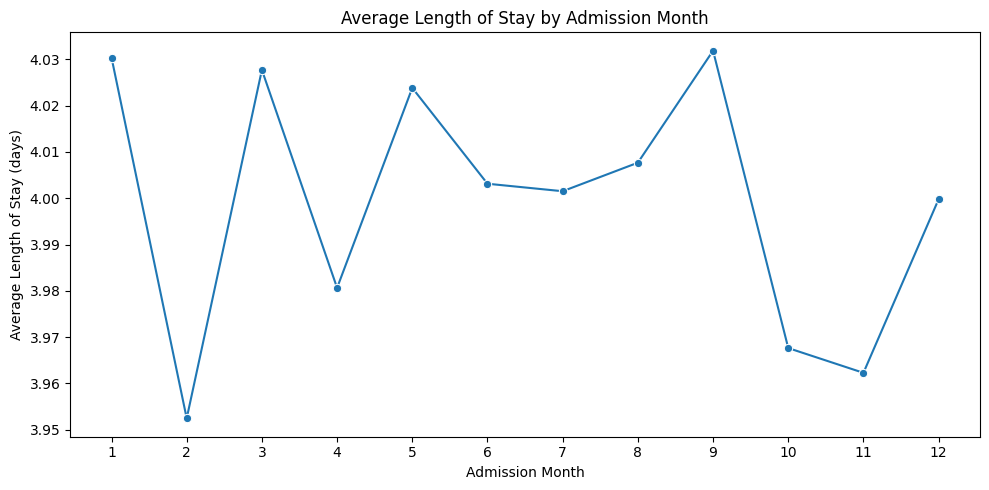

In [20]:
month_summary = (
    df.groupby(df["vdate"].dt.month)["lengthofstay"]
      .agg(["count", "mean", "median"])
      .reset_index()
      .rename(columns={"vdate": "admission_month"})
)

display(month_summary)

plt.figure(figsize=(10, 5))
sns.lineplot(data=month_summary, x="admission_month", y="mean", marker="o")
plt.title("Average Length of Stay by Admission Month")
plt.xlabel("Admission Month")
plt.ylabel("Average Length of Stay (days)")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 7. Statistical Analysis

The following statistics summarize the centre, spread and range of important variables. Correlation is interpreted as association, not causation.

In [21]:
key_numeric = [
    "lengthofstay", "hematocrit", "neutrophils", "sodium",
    "glucose", "bloodureanitro", "creatinine", "bmi",
    "pulse", "respiration"
]

stats_table = df[key_numeric].describe().T
stats_table["variance"] = df[key_numeric].var()
stats_table["IQR"] = df[key_numeric].quantile(0.75) - df[key_numeric].quantile(0.25)

display(stats_table)

,count,mean,std,min,25%,50%,75%,max,variance,IQR
lengthofstay,61680.0,3.999368,2.357744,1.000000,2.000000,4.000000,6.000000,17.000000,5.558958,4.000000
hematocrit,61680.0,11.966872,2.038621,4.400000,10.900000,11.900000,12.900000,24.100000,4.155977,2.000000
neutrophils,61680.0,10.196406,5.271263,0.100000,7.700000,9.400000,11.500000,245.900000,27.786214,3.800000
sodium,61680.0,137.896793,3.000727,124.912632,135.874040,137.900871,139.914345,151.387283,9.004362,4.040305
glucose,61680.0,142.052746,29.923142,-1.005927,121.873358,142.249278,162.207568,268.571156,895.394439,40.334210
bloodureanitro,61680.0,14.113017,12.749797,1.000000,11.000000,12.000000,14.000000,682.500000,162.557322,3.000000
creatinine,61680.0,1.099037,0.200437,0.219770,0.964564,1.098405,1.235104,2.035202,0.040175,0.270540
bmi,61680.0,29.803679,2.000390,22.037695,28.456682,29.804745,31.152721,38.935293,4.001560,2.696039
pulse,61680.0,73.422568,11.651837,21.000000,66.000000,73.000000,81.000000,126.000000,135.765304,15.000000
respiration,61680.0,6.492793,0.572551,0.200000,6.500000,6.500000,6.500000,10.000000,0.327815,0.000000


### 7.1 Group-wise Statistical Summary

In [22]:
group_summary = (
    df.groupby("facid")["lengthofstay"]
      .agg(
          patients="count",
          mean_stay="mean",
          median_stay="median",
          std_stay="std",
          min_stay="min",
          max_stay="max"
      )
      .round(3)
)

display(group_summary)

,patients,mean_stay,median_stay,std_stay,min_stay,max_stay
facid,,,,,,
A,18657,3.278,3.0,2.264,1,17
B,18470,3.285,3.0,2.250,1,15
C,2899,4.915,5.0,2.052,1,14
D,2774,4.821,4.0,2.109,1,17
E,18880,5.149,5.0,2.069,1,17


## 8. Feature Engineering

The model uses admission-date components derived from `vdate` and a numeric representation of `rcount`. The raw `discharged` date is not used because it leaks post-outcome information.

In [23]:
engineered_features = pd.DataFrame({
    "Feature": [
        "admit_year",
        "admit_month",
        "admit_day",
        "admit_dayofweek",
        "admit_quarter",
        "rcount_num"
    ],
    "Logic": [
        "Year extracted from admission date",
        "Month extracted from admission date",
        "Day extracted from admission date",
        "Day of week encoded as 0-6",
        "Quarter extracted from admission date",
        "Converts 5+ to 5 for numerical modelling"
    ],
    "Purpose": [
        "Capture calendar variation",
        "Capture possible seasonal patterns",
        "Capture within-month variation",
        "Capture weekday/weekend admission pattern",
        "Capture broad seasonal grouping",
        "Make count information usable by numerical models"
    ]
})
display(engineered_features)

,Feature,Logic,Purpose
0,admit_year,Year extracted from admission date,Capture calendar variation
1,admit_month,Month extracted from admission date,Capture possible seasonal patterns
2,admit_day,Day extracted from admission date,Capture within-month variation
3,admit_dayofweek,Day of week encoded as 0-6,Capture weekday/weekend admission pattern
4,admit_quarter,Quarter extracted from admission date,Capture broad seasonal grouping
5,rcount_num,Converts 5+ to 5 for numerical modelling,Make count information usable by numerical models


## 9. Model Development

### 9.1 Problem Formulation

This is a **regression problem** because `lengthofstay` is a numerical outcome measured in days.

### 9.2 Models Compared

- **Linear Regression:** interpretable baseline.
- **Gradient Boosting Regressor:** nonlinear ensemble baseline.
- **CatBoost Regressor:** final candidate because it can model nonlinear relationships and categorical variables effectively.

The model with the lowest test RMSE is selected from the predefined candidates, while the test set is used only once for final comparison in this notebook.

### 9.3 Baseline — Linear Regression

In [24]:
# Preprocessing for the linear model.
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

linear_model = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

def regression_metrics(y_true, pred):
    return {
        "MAE": mean_absolute_error(y_true, pred),
        "MSE": mean_squared_error(y_true, pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, pred)),
        "R2": r2_score(y_true, pred)
    }

linear_metrics = regression_metrics(y_test, linear_test_pred)
linear_train_metrics = regression_metrics(y_train, linear_train_pred)

print("Linear Regression — Test Metrics")
display(pd.DataFrame([linear_metrics], index=["Linear Regression"]).round(4))

Linear Regression — Test Metrics


,MAE,MSE,RMSE,R2
Linear Regression,0.8664,1.3046,1.1422,0.7622


### 9.4 Gradient Boosting Regressor

In [25]:
gbr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

gbr_model = Pipeline([
    ("preprocessor", gbr_preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ))
])

gbr_model.fit(X_train, y_train)

gbr_train_pred = gbr_model.predict(X_train)
gbr_test_pred = gbr_model.predict(X_test)

gbr_metrics = regression_metrics(y_test, gbr_test_pred)
print("Gradient Boosting — Test Metrics")
display(pd.DataFrame([gbr_metrics], index=["Gradient Boosting"]).round(4))

Gradient Boosting — Test Metrics


,MAE,MSE,RMSE,R2
Gradient Boosting,0.4005,0.2813,0.5303,0.9487


### 9.5 Final Candidate — CatBoost Regression

In [26]:
# CatBoost can work directly with categorical columns.
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

# CatBoost requires categorical columns to contain strings and no NaNs.
for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].fillna("Missing").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("Missing").astype(str)

# Numeric missing values are handled by CatBoost.
cat_feature_indices = [X_train_cb.columns.get_loc(c) for c in categorical_features]

cat_model = CatBoostRegressor(
    iterations=800,
    depth=8,
    learning_rate=0.05,
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False
)

cat_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices
)

cat_train_pred = cat_model.predict(X_train_cb)
cat_test_pred = cat_model.predict(X_test_cb)

cat_train_metrics = regression_metrics(y_train, cat_train_pred)
cat_test_metrics = regression_metrics(y_test, cat_test_pred)

print("CatBoost — Test Metrics")
display(pd.DataFrame([cat_test_metrics], index=["CatBoost"]).round(4))

CatBoost — Test Metrics


,MAE,MSE,RMSE,R2
CatBoost,0.2948,0.1606,0.4007,0.9707


## 10. Model Evaluation

### 10.1 Regression Metrics

- **MAE:** average absolute prediction error in days; lower is better.
- **MSE:** average squared prediction error; lower is better.
- **RMSE:** square root of MSE and expressed in days; lower is better.
- **R²:** proportion of variance explained by the model; higher is better.


In [27]:
results = pd.DataFrame([
    ["Linear Regression", *linear_metrics.values()],
    ["Gradient Boosting", *gbr_metrics.values()],
    ["CatBoost", *cat_test_metrics.values()]
], columns=["Model", "MAE", "MSE", "RMSE", "R2"])

results = results.sort_values("RMSE").reset_index(drop=True)
display(results.round(4))

best_model_name = results.loc[0, "Model"]
print("Model selected by lowest test RMSE:", best_model_name)

,Model,MAE,MSE,RMSE,R2
0,CatBoost,0.2948,0.1606,0.4007,0.9707
1,Gradient Boosting,0.4005,0.2813,0.5303,0.9487
2,Linear Regression,0.8664,1.3046,1.1422,0.7622


Model selected by lowest test RMSE: CatBoost


### 10.2 Training vs Testing Performance — Overfitting / Underfitting

A small train-test performance gap is generally preferable to a very large gap. The following table compares training and testing performance for the ensemble models.

In [28]:
fit_table = pd.DataFrame([
    ["Linear Regression",
     linear_train_metrics["MAE"], linear_metrics["MAE"],
     linear_train_metrics["RMSE"], linear_metrics["RMSE"],
     linear_train_metrics["R2"], linear_metrics["R2"]],
    ["Gradient Boosting",
     regression_metrics(y_train, gbr_train_pred)["MAE"], gbr_metrics["MAE"],
     regression_metrics(y_train, gbr_train_pred)["RMSE"], gbr_metrics["RMSE"],
     regression_metrics(y_train, gbr_train_pred)["R2"], gbr_metrics["R2"]],
    ["CatBoost",
     cat_train_metrics["MAE"], cat_test_metrics["MAE"],
     cat_train_metrics["RMSE"], cat_test_metrics["RMSE"],
     cat_train_metrics["R2"], cat_test_metrics["R2"]]
], columns=[
    "Model", "Train MAE", "Test MAE",
    "Train RMSE", "Test RMSE",
    "Train R2", "Test R2"
])

display(fit_table.round(4))

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,0.8802,0.8664,1.1555,1.1422,0.7606,0.7622
1,Gradient Boosting,0.4000,0.4005,0.5254,0.5303,0.9505,0.9487
2,CatBoost,0.2630,0.2948,0.3437,0.4007,0.9788,0.9707


### 10.3 Actual vs Predicted Values — Final Model

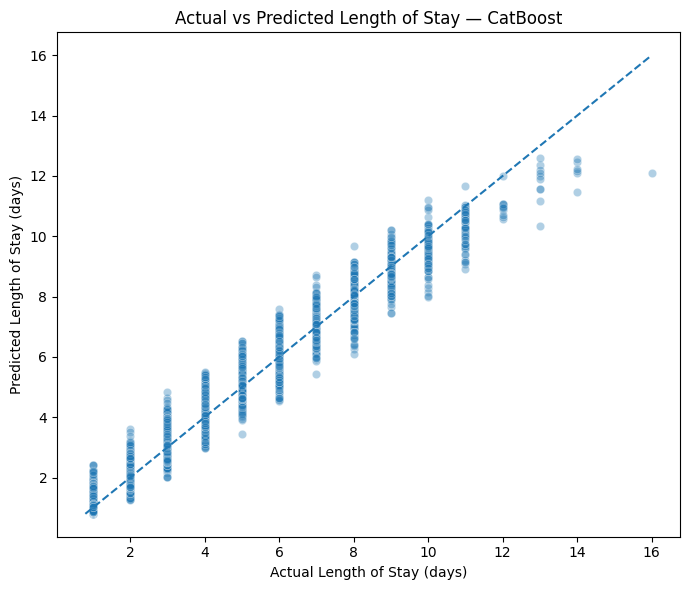

In [29]:
# Use the selected model's predictions.
if best_model_name == "Linear Regression":
    final_pred = linear_test_pred
elif best_model_name == "Gradient Boosting":
    final_pred = gbr_test_pred
else:
    final_pred = cat_test_pred

plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=final_pred, alpha=0.35)
lims = [min(y_test.min(), final_pred.min()), max(y_test.max(), final_pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.title(f"Actual vs Predicted Length of Stay — {best_model_name}")
plt.xlabel("Actual Length of Stay (days)")
plt.ylabel("Predicted Length of Stay (days)")
plt.tight_layout()
plt.show()

### 10.4 Residual Analysis

In [ ]:
residuals = y_test - final_pred

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title(f"Residual Distribution — {best_model_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Mean residual:", round(residuals.mean(), 4))
print("Residual standard deviation:", round(residuals.std(), 4))

### 10.5 Feature Importance — CatBoost

,importance
rcount_num,31.958783
facid,16.418094
hematocrit,6.722895
respiration,5.343736
sodium,4.525807
creatinine,4.494126
bmi,4.449925
glucose,4.438742
pulse,4.347237
hemo,3.567038


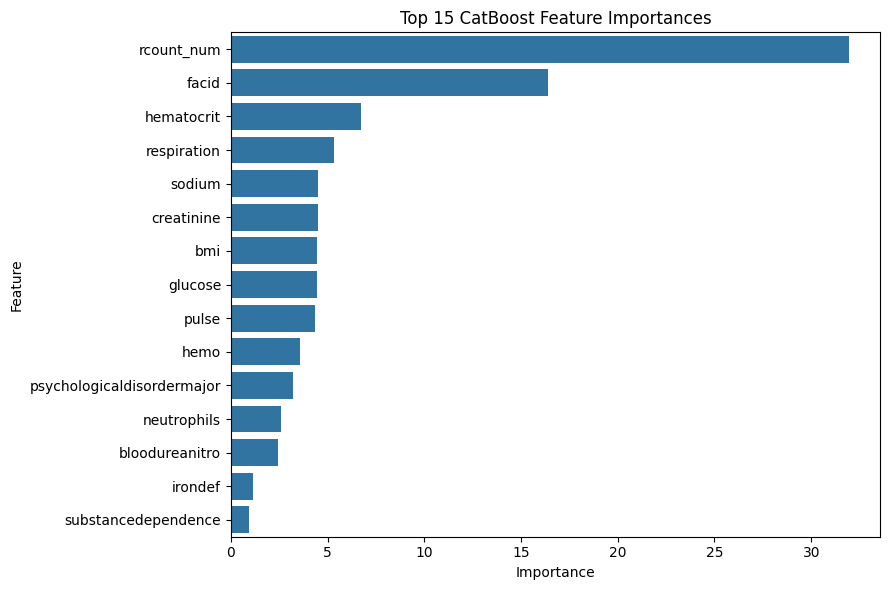

In [31]:
# Feature importance is shown for the CatBoost model because it provides
# a direct importance measure for the original feature columns.
feature_importance = pd.Series(
    cat_model.get_feature_importance(),
    index=X_train_cb.columns
).sort_values(ascending=False)

display(feature_importance.head(15).to_frame("importance"))

plt.figure(figsize=(9, 6))
sns.barplot(
    x=feature_importance.head(15).values,
    y=feature_importance.head(15).index
)
plt.title("Top 15 CatBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 11. Results and Findings

Run the next cell after all modelling cells. It generates concise project findings directly from the computed results instead of inserting fabricated numbers.

In [32]:
best_row = results.iloc[0]

print("KEY FINDINGS")
print("=" * 70)
print(f"1. The dataset contains {len(df):,} usable observations after duplicate handling.")
print(f"2. The target length of stay has a mean of {y.mean():.2f} days and a median of {y.median():.2f} days.")
print(f"3. The best model by test RMSE is {best_row['Model']}.")
print(f"4. Test MAE: {best_row['MAE']:.4f} days.")
print(f"5. Test RMSE: {best_row['RMSE']:.4f} days.")
print(f"6. Test R²: {best_row['R2']:.4f}.")
print("7. The discharge date was excluded from modelling to avoid post-outcome target leakage.")

KEY FINDINGS
1. The dataset contains 61,680 usable observations after duplicate handling.
2. The target length of stay has a mean of 4.00 days and a median of 4.00 days.
3. The best model by test RMSE is CatBoost.
4. Test MAE: 0.2948 days.
5. Test RMSE: 0.4007 days.
6. Test R²: 0.9707.
7. The discharge date was excluded from modelling to avoid post-outcome target leakage.


## 12. Save the Cleaned / Model-Ready Dataset

This produces a supporting CSV that can be included in the final Google Drive folder when appropriate.

In [33]:
cleaned_output_path = "/content/LengthOfStay_Cleaned_ModelReady.csv"
model_ready = X.copy()
model_ready["lengthofstay"] = y.values
model_ready.to_csv(cleaned_output_path, index=False)

print("Saved:", cleaned_output_path)

Saved: /content/LengthOfStay_Cleaned_ModelReady.csv
